# 05 — Feature Engineering (modelo supervisionado de recompra)

## Abordagem: classificação supervisionada de recompra

Um modelo que recebe apenas **IDs** (usuário e produto) não tem acesso a *com que
frequência* nem *há quanto tempo* o usuário compra cada item — sinais centrais
para prever recompra. Por isso descrevemos cada par usuário-produto com
**features explícitas**.

**A tarefa.** Para cada produto que o usuário já comprou (*candidato*), criamos
*features* (frequência, recência, taxas de reorder, popularidade) e um **rótulo**:
o produto apareceu no próximo pedido (`train`)? A MLP do notebook 06 aprende
`P(recompra | features, embedding do produto)`. Lá comparamos **diretamente** esta
abordagem com um NCF baseado só em IDs, medindo qual ranqueia melhor.

> 🔑 **Decisão de design — sem embedding de ID de usuário.** Como avaliamos em
> usuários *held-out* (nunca vistos no treino), um embedding de ID de usuário
> seria um vetor aleatório para eles (*cold-start*). Representamos o usuário por
> **features agregadas** e mantemos **embedding de produto** (todos os produtos
> são vistos no treino). É a escolha que **generaliza** para usuários novos.

## 0. Setup

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

SEED = 42
np.random.seed(SEED)
pd.set_option('display.max_columns', 50)


def find_project_root(marker: str = 'pyproject.toml') -> Path:
    '''Sobe na arvore de diretorios ate encontrar o marcador do projeto.'''
    current = Path.cwd()
    for parent in [current, *current.parents]:
        if (parent / marker).exists():
            return parent
    raise FileNotFoundError(f'Marcador {marker} nao encontrado a partir de {current}')


PROJECT_ROOT = find_project_root()
RAW_DIR = PROJECT_ROOT / 'data' / 'raw'
PROCESSED_DIR = PROJECT_ROOT / 'data' / 'processed'
IMG_DIR = PROJECT_ROOT / 'docs' / 'img' / 'features'
IMG_DIR.mkdir(parents=True, exist_ok=True)
print('Raw      :', RAW_DIR)
print('Processed:', PROCESSED_DIR)

Raw      : c:\Users\erick\projetos\mlp-market-recommender-system\data\raw
Processed: c:\Users\erick\projetos\mlp-market-recommender-system\data\processed


## 1. Candidatos e rótulos

- **Candidatos:** cada par (usuário, produto) do histórico (`interactions`).
- **Rótulo:** 1 se o produto está no próximo pedido real (`val_ground_truth`),
  senão 0. Só usamos usuários que têm pedido `train` (os rotulados).

In [2]:
def build_candidates(interactions: pd.DataFrame, val: pd.DataFrame) -> pd.DataFrame:
    '''Monta candidatos (user, product) rotulados com 1 se estao no proximo pedido.'''
    valid = val.dropna(subset=['product_idx']).copy()
    valid['user_idx'] = valid['user_idx'].astype('int32')
    valid['product_idx'] = valid['product_idx'].astype('int32')
    labeled = set(valid['user_idx'].unique())
    candidates = interactions[interactions['user_idx'].isin(labeled)].copy()
    positives = valid[['user_idx', 'product_idx']].assign(label=np.int8(1))
    candidates = candidates.merge(positives, on=['user_idx', 'product_idx'], how='left')
    candidates['label'] = candidates['label'].fillna(0).astype('int8')
    return candidates


interactions = pd.read_parquet(PROCESSED_DIR / 'interactions.parquet')
val = pd.read_parquet(PROCESSED_DIR / 'val_ground_truth.parquet')
candidates = build_candidates(interactions, val)
print('Candidatos :', f'{len(candidates):,}')
print('Positivos  :', f"{candidates['label'].mean() * 100:.1f}%")
candidates.head()

Candidatos : 8,474,661
Positivos  : 9.8%


,user_id,product_id,n_orders,n_reorders,user_idx,product_idx,label
0,1,196,10,9,0,195,1
1,1,10258,9,8,0,10254,1
2,1,10326,1,0,0,10322,0
3,1,12427,10,9,0,12423,0
4,1,13032,3,2,0,13028,1


## 2. Features de usuário-produto e de usuário

- `up_reorder_rate` — quão recorrente é o par (recompras / compras).
- `up_order_share` — fração dos pedidos do usuário que contêm o item (frequência
  normalizada — o sinal central do baseline de histórico).
- `u_*` — perfil do usuário (nº de pedidos, variedade, propensão a reorder).

In [3]:
def add_user_product_features(candidates: pd.DataFrame, orders: pd.DataFrame) -> pd.DataFrame:
    '''Adiciona features do par (usuario, produto) e o nº de pedidos do usuario.'''
    n_orders = (orders[orders['eval_set'] == 'prior']
                .groupby('user_id').size().rename('u_n_orders'))
    candidates = candidates.merge(n_orders, on='user_id', how='left')
    candidates['up_order_share'] = candidates['n_orders'] / candidates['u_n_orders']
    candidates['up_reorder_rate'] = (
        candidates['n_reorders'] / candidates['n_orders'].clip(lower=1)
    )
    return candidates


def add_user_features(candidates: pd.DataFrame) -> pd.DataFrame:
    '''Adiciona o perfil agregado do usuario (variedade e taxa de reorder).'''
    agg = candidates.groupby('user_idx').agg(
        u_n_products=('product_idx', 'size'),
        u_reorder_sum=('n_reorders', 'sum'),
        u_order_sum=('n_orders', 'sum'))
    agg['u_reorder_rate'] = agg['u_reorder_sum'] / agg['u_order_sum'].clip(lower=1)
    return candidates.merge(
        agg[['u_n_products', 'u_reorder_rate']], on='user_idx', how='left')


orders = pd.read_csv(
    RAW_DIR / 'orders.csv',
    usecols=['order_id', 'user_id', 'eval_set', 'order_number'],
    dtype={'order_id': 'int32', 'user_id': 'int32',
           'eval_set': 'category', 'order_number': 'int16'})
candidates = add_user_product_features(candidates, orders)
candidates = add_user_features(candidates)
print('Colunas:', list(candidates.columns))

Colunas: ['user_id', 'product_id', 'n_orders', 'n_reorders', 'user_idx', 'product_idx', 'label', 'u_n_orders', 'up_order_share', 'up_reorder_rate', 'u_n_products', 'u_reorder_rate']


## 3. Features de recência ⭐

A **recência** é o sinal que o baseline de frequência **não tem** — e o que mais
ajuda a MLP a vencê-lo. Para cada par (usuário, produto), calculamos a partir do
histórico bruto:

- `up_orders_since_last` — há quantos pedidos o usuário comprou o item pela
  última vez (0 = comprou no pedido mais recente → forte sinal de recompra).
- `up_active_span` — janela de pedidos entre a 1ª compra do item e o último
  pedido do usuário.
- `up_purchase_rate` — compras do item por pedido dentro dessa janela.

In [4]:
def build_recency(raw_dir: Path) -> pd.DataFrame:
    '''Calcula, por (user, product), a recencia da ultima compra no historico.'''
    products = pd.read_csv(
        raw_dir / 'order_products__prior.csv', usecols=['order_id', 'product_id'],
        dtype={'order_id': 'int32', 'product_id': 'int32'})
    order_nums = pd.read_csv(
        raw_dir / 'orders.csv', usecols=['order_id', 'user_id', 'order_number', 'eval_set'],
        dtype={'order_id': 'int32', 'user_id': 'int32',
               'order_number': 'int16', 'eval_set': 'category'})
    order_nums = order_nums[order_nums['eval_set'] == 'prior']
    merged = products.merge(order_nums[['order_id', 'user_id', 'order_number']], on='order_id')
    u_max = merged.groupby('user_id')['order_number'].max().rename('u_max_order')
    recency = merged.groupby(['user_id', 'product_id']).agg(
        up_last=('order_number', 'max'), up_first=('order_number', 'min')).reset_index()
    recency = recency.merge(u_max, on='user_id')
    recency['up_orders_since_last'] = (recency['u_max_order'] - recency['up_last']).astype('int16')
    recency['up_active_span'] = (recency['u_max_order'] - recency['up_first'] + 1).astype('int16')
    return recency[['user_id', 'product_id', 'up_orders_since_last', 'up_active_span']]


recency = build_recency(RAW_DIR)
candidates = candidates.merge(recency, on=['user_id', 'product_id'], how='left')
candidates['up_purchase_rate'] = (
    candidates['n_orders'] / candidates['up_active_span'].clip(lower=1))
print('Recência adicionada. Exemplo:')
candidates[['n_orders', 'up_orders_since_last', 'up_active_span', 'up_purchase_rate', 'label']].head()

Recência adicionada. Exemplo:


,n_orders,up_orders_since_last,up_active_span,up_purchase_rate,label
0,10,0,10,1.000000,1
1,9,0,9,1.000000,1
2,1,5,6,0.166667,0
3,10,0,10,1.000000,0
4,3,0,9,0.333333,1


## 4. Features de produto e metadados (para embeddings)

- `p_n_users` (popularidade) e `p_reorder_rate` (propensão global a reorder).
- `aisle_id` e `department_id` — categorias do produto, que viram **embeddings**
  no modelo (capturam similaridade entre produtos da mesma seção).

In [5]:
def add_product_features(candidates: pd.DataFrame, interactions: pd.DataFrame) -> pd.DataFrame:
    '''Adiciona popularidade e taxa de reorder global por produto.'''
    agg = interactions.groupby('product_idx').agg(
        p_n_users=('user_idx', 'size'),
        p_order_sum=('n_orders', 'sum'),
        p_reorder_sum=('n_reorders', 'sum'))
    agg['p_reorder_rate'] = agg['p_reorder_sum'] / agg['p_order_sum'].clip(lower=1)
    return candidates.merge(agg[['p_n_users', 'p_reorder_rate']], on='product_idx', how='left')


def add_product_metadata(candidates: pd.DataFrame, raw_dir: Path) -> pd.DataFrame:
    '''Adiciona aisle_id e department_id (entram como embeddings no modelo).'''
    products = pd.read_csv(
        raw_dir / 'products.csv', usecols=['product_id', 'aisle_id', 'department_id'],
        dtype={'product_id': 'int32', 'aisle_id': 'int16', 'department_id': 'int8'})
    return candidates.merge(products, on='product_id', how='left')


candidates = add_product_features(candidates, interactions)
candidates = add_product_metadata(candidates, RAW_DIR)
print('aisles:', candidates['aisle_id'].nunique(), '| departments:', candidates['department_id'].nunique())
candidates.head()

aisles: 134 | departments: 21


,user_id,product_id,n_orders,n_reorders,user_idx,product_idx,label,u_n_orders,up_order_share,up_reorder_rate,u_n_products,u_reorder_rate,up_orders_since_last,up_active_span,up_purchase_rate,p_n_users,p_reorder_rate,aisle_id,department_id
0,1,196,10,9,0,195,1,10,1.0,0.900000,18,0.694915,0,10,1.000000,8000,0.776480,77,7
1,1,10258,9,8,0,10254,1,10,0.9,0.888889,18,0.694915,0,9,1.000000,557,0.713772,117,19
2,1,10326,1,0,0,10322,0,10,0.1,0.000000,18,0.694915,5,6,0.166667,1923,0.652009,24,4
3,1,12427,10,9,0,12423,0,10,1.0,0.900000,18,0.694915,0,10,1.000000,1679,0.740735,23,19
4,1,13032,3,2,0,13028,1,10,0.3,0.666667,18,0.694915,0,9,0.333333,1286,0.657158,121,14


## 5. A recência prevê recompra?

Validação visual rápida: a probabilidade de recompra **cai** conforme aumenta o
nº de pedidos desde a última compra. Se a curva for decrescente, a feature é boa.

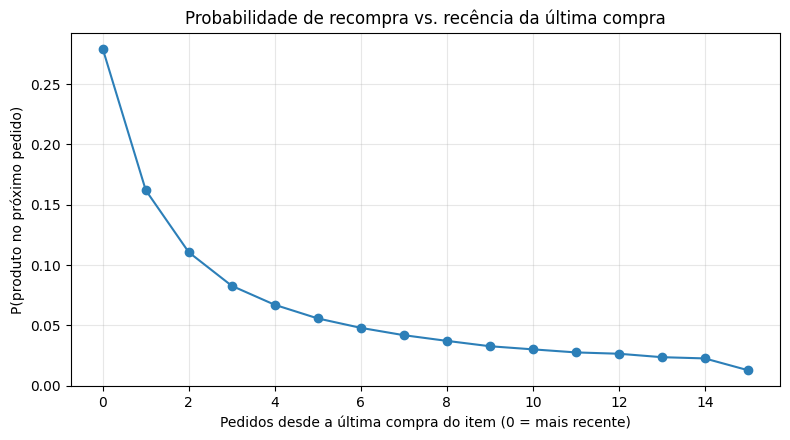

In [6]:
bucket = candidates['up_orders_since_last'].clip(upper=15)
reorder_prob = candidates.groupby(bucket)['label'].mean()

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.plot(reorder_prob.index, reorder_prob.values, marker='o', color='#2c7fb8')
ax.set_title('Probabilidade de recompra vs. recência da última compra')
ax.set_xlabel('Pedidos desde a última compra do item (0 = mais recente)')
ax.set_ylabel('P(produto no próximo pedido)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(IMG_DIR / '01_recency_vs_reorder.png', dpi=120, bbox_inches='tight')
plt.show()

## 6. Split por usuário (sem leakage)

Separamos os **usuários** em treino (80%) e avaliação (20%). Como os rótulos vêm
do próximo pedido, dividir por usuário garante que o modelo **nunca vê** o pedido
de avaliação — evitando vazamento.

In [7]:
def assign_split(candidates: pd.DataFrame, seed: int, eval_frac: float = 0.2) -> pd.DataFrame:
    '''Marca cada candidato como 'train' ou 'eval' por usuario (sem leakage).'''
    users = np.sort(candidates['user_idx'].unique())
    rng = np.random.default_rng(seed)
    rng.shuffle(users)
    n_eval = int(eval_frac * len(users))
    eval_users = set(users[:n_eval])
    split = np.where(candidates['user_idx'].isin(eval_users), 'eval', 'train')
    return candidates.assign(split=split)


candidates = assign_split(candidates, SEED)
print(candidates['split'].value_counts())
print('Usuários eval:', f"{candidates.loc[candidates['split'] == 'eval', 'user_idx'].nunique():,}")

split
train    6783995
eval     1690666
Name: count, dtype: int64
Usuários eval: 26,241


## 7. Salvar a tabela de features

In [8]:
FEATURE_COLS = [
    'n_orders', 'up_order_share', 'up_reorder_rate', 'up_orders_since_last',
    'up_active_span', 'up_purchase_rate', 'u_n_products', 'u_reorder_rate',
    'p_n_users', 'p_reorder_rate']
KEEP = ['user_idx', 'product_idx', 'aisle_id', 'department_id', *FEATURE_COLS, 'label', 'split']

features = candidates[KEEP].copy()
features.to_parquet(PROCESSED_DIR / 'candidate_features.parquet', index=False)
print('Salvo candidate_features.parquet:', features.shape)
print('Features numéricas:', FEATURE_COLS)
features.head()

Salvo candidate_features.parquet: (8474661, 16)
Features numéricas: ['n_orders', 'up_order_share', 'up_reorder_rate', 'up_orders_since_last', 'up_active_span', 'up_purchase_rate', 'u_n_products', 'u_reorder_rate', 'p_n_users', 'p_reorder_rate']


,user_idx,product_idx,aisle_id,department_id,n_orders,up_order_share,up_reorder_rate,up_orders_since_last,up_active_span,up_purchase_rate,u_n_products,u_reorder_rate,p_n_users,p_reorder_rate,label,split
0,0,195,77,7,10,1.0,0.900000,0,10,1.000000,18,0.694915,8000,0.776480,1,train
1,0,10254,117,19,9,0.9,0.888889,0,9,1.000000,18,0.694915,557,0.713772,1,train
2,0,10322,24,4,1,0.1,0.000000,5,6,0.166667,18,0.694915,1923,0.652009,0,train
3,0,12423,23,19,10,1.0,0.900000,0,10,1.000000,18,0.694915,1679,0.740735,0,train
4,0,13028,121,14,3,0.3,0.666667,0,9,0.333333,18,0.694915,1286,0.657158,1,train


## 8. Resumo

- Construímos **~8,5M candidatos rotulados** (9,8% positivos) com features de
  frequência, **recência**, reorder e popularidade, mais `aisle_id`/`department_id`
  para embeddings.
- Split por usuário (80/20) **sem leakage**, pronto para treino e avaliação.
- A curva de recência confirma: quanto mais recente a última compra, maior a
  chance de recompra — o sinal que falta aos baselines.

**Próximo passo (`notebook 06`):** treinar a **MLP** (embeddings de produto +
aisle/department + features numéricas) com *early stopping*, e a comparação final
contra os baselines, provando que o modelo neural é o melhor.